In [19]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:

# List the 6 monthly files
files = [
    "../data/CRMLSSold202512.csv",
    "../data/CRMLSSold202601.csv",
    "../data/CRMLSSold202602.csv",
    "../data/CRMLSSold202603.csv",
    "../data/CRMLSSold202604.csv",
    "../data/CRMLSSold202605.csv",
]

In [13]:

# Load and combine all months into one dataframe
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print(f"Total rows loaded: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(df.head())

C:\Users\linji\AppData\Local\Temp\ipykernel_33160\2414189015.py:2: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


Total rows loaded: 124404
Total columns: 78
  BuyerAgentAOR ListAgentAOR          Flooring ViewYN WaterfrontYN BasementYN  \
0   ContraCosta  ContraCosta  Carpet,Tile,Wood    NaN          NaN        NaN   
1   Mlslistings  Mlslistings               NaN  False          NaN        NaN   
2      SanDiego     SanDiego       Carpet,Wood   True          NaN        NaN   
3   Mlslistings  Mlslistings               NaN  False          NaN        NaN   
4   TriCounties  TriCounties               NaN   True          NaN        NaN   

  PoolPrivateYN  OriginalListPrice  ListingKey  \
0         False          1998000.0  1150041639   
1           NaN                NaN  1150038872   
2         False          2214421.0  1150038683   
3           NaN          1200000.0  1150038607   
4          True             3300.0  1150038314   

                     ListAgentEmail  ... LotSizeDimensions  LotSizeArea  \
0           teresa@teresahooper.com  ...               NaN      10080.0   
1           homes@

In [14]:
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]

print(f"Rows after filtering: {len(df)}")

Rows after filtering: 61727


In [17]:
# Summary stats for key columns
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
print(df[cols].describe())

         ClosePrice    LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  6.172700e+04  61697.000000   61727.000000           61726.000000   
mean   1.340106e+06   2055.552918       3.498437               2.644801   
std    7.307629e+06   1037.243701       0.966684               1.135026   
min    1.750000e+00      0.000000       0.000000               0.000000   
25%    6.200000e+05   1386.000000       3.000000               2.000000   
50%    8.900000e+05   1826.000000       3.000000               2.000000   
75%    1.425000e+06   2455.000000       4.000000               3.000000   
max    7.960000e+08  23314.000000      22.000000              22.000000   

       LotSizeSquareFeet  
count       6.064600e+04  
mean        3.859489e+05  
std         1.843401e+07  
min         0.000000e+00  
25%         5.663000e+03  
50%         7.263500e+03  
75%         1.045400e+04  
max         1.897474e+09  


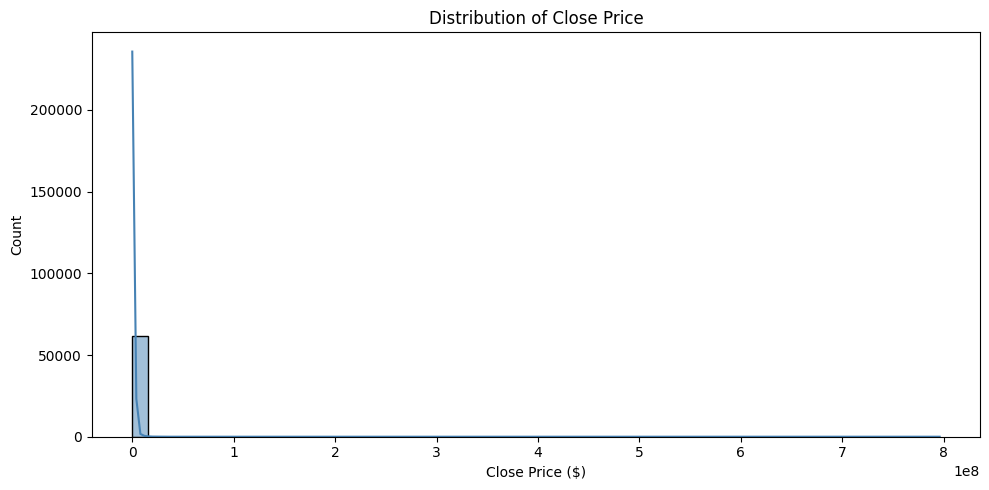

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df["ClosePrice"].dropna(), bins=50, kde=True, color="steelblue")
plt.title("Distribution of Close Price")
plt.xlabel("Close Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

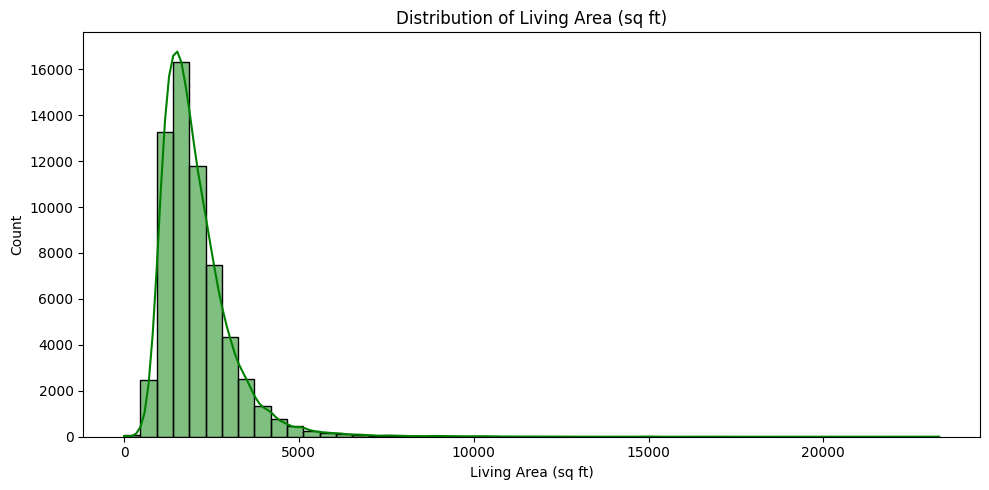

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(df["LivingArea"].dropna(), bins=50, kde=True, color="green")
plt.title("Distribution of Living Area (sq ft)")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

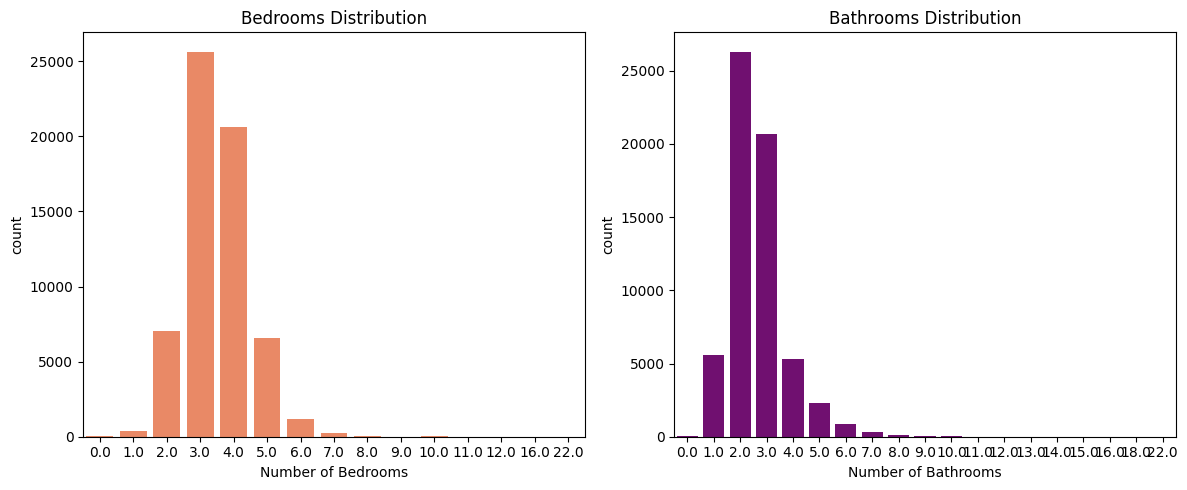

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=df["BedroomsTotal"].dropna(), ax=axes[0], color="coral")
axes[0].set_title("Bedrooms Distribution")
axes[0].set_xlabel("Number of Bedrooms")

sns.countplot(x=df["BathroomsTotalInteger"].dropna(), ax=axes[1], color="purple")
axes[1].set_title("Bathrooms Distribution")
axes[1].set_xlabel("Number of Bathrooms")

plt.tight_layout()
plt.show()

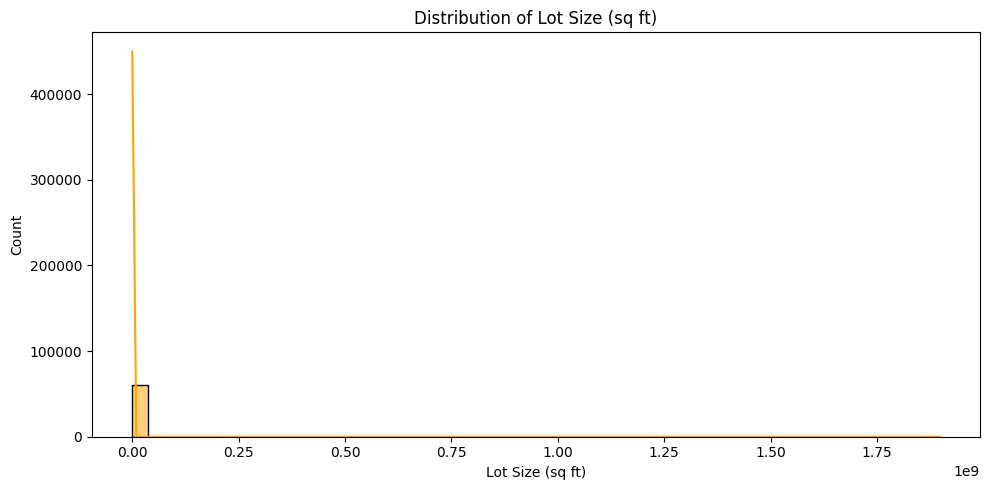

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(df["LotSizeSquareFeet"].dropna(), bins=50, kde=True, color="orange")
plt.title("Distribution of Lot Size (sq ft)")
plt.xlabel("Lot Size (sq ft)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

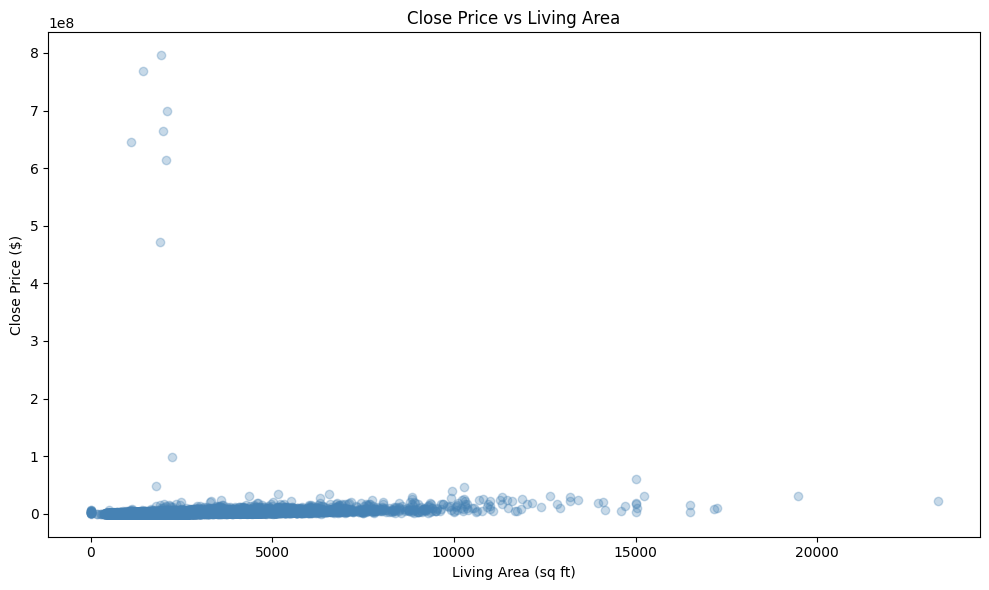

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(df["LivingArea"], df["ClosePrice"], alpha=0.3, color="steelblue")
plt.title("Close Price vs Living Area")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Close Price ($)")
plt.tight_layout()
plt.show()